<a href="https://colab.research.google.com/github/AYUSHUMARE259/Approx-Computing-/blob/main/image_blending_application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

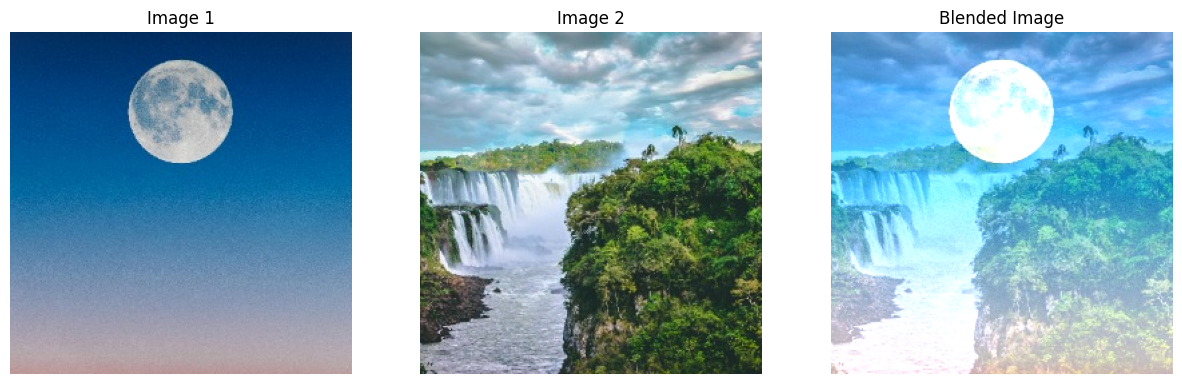

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Local image paths
image1_path = "/content/moon_1-256x256.jpg"
image2_path = "/content/pexels-jonnylew-1928279-256x256.jpg"

# Read the images using OpenCV
image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)

# Resize both images to same size (optional, but needed for blending)
image1 = cv2.resize(image1, (256, 256))
image2 = cv2.resize(image2, (256, 256))

# Set blending weights
alpha = 1
beta = 0.6

# Blend the images
blended_image = cv2.addWeighted(image1, alpha, image2, beta, 0.5)

# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
plt.title('Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
plt.title('Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title('Blended Image')
plt.axis('off')

plt.show()


In [ ]:
#__________compressor lut's __________#
def momeni_compressor(x4, x3, x2, x1):
    bits = [x4, x3, x2, x1]
    sum0_carry1 = [[0,0,0,0], [0,0,0,1], [0,0,1,0], [0,0,1,1],[0,1,0,0], [1,0,0,0], [1,1,0,0]]
    sum1_carry0 = [[0,1,0,1], [0,1,1,0], [1,0,0,1], [1,0,1,0]]
    if bits in sum0_carry1:
        return 0, 1
    elif bits in sum1_carry0:
        return 1, 0
    else:
        return 1, 1
def venka_compressor(x4, x3, x2, x1):
    bits = [x4, x3, x2, x1]
    sum0_carry0 = [[0,0,0,0]]
    sum1_carry1 = [[0,1,1,1], [1,0,1,1], [1,1,0,1], [1,1,1,0], [1,1,1,1]]
    sum1_carry0 = [[0,0,1,1], [1,1,0,0]]
    if bits in sum0_carry0:
        return 0, 0
    elif bits in sum1_carry0:
        return 1, 0
    elif bits in sum1_carry1:
        return 1, 1
    else:
        return 0, 1

def yang2_compressor(x4, x3, x2, x1):
    bits = [x4, x3, x2, x1]
    sum0_carry0 = [[0,0,0,0]]
    sum0_carry1 = [[0,0,0,1], [0,0,1,0], [0,1,0,0], [1,0,0,0]]
    sum1_carry0 = [[0,0,1,1], [0,1,0,1],[1,0,0,1],[0,1,1,0], [1,0,1,0]]
    if bits in sum0_carry0:
        return 0, 0
    elif bits in sum0_carry1:
        return 0, 1
    elif bits in sum1_carry0:
        return 1, 0
    else:
        return 1, 1
def akbar2_compressor(x4, x3, x2, x1):
    bits = [x4, x3, x2, x1]
    sum0_carry0 = [[0,0,0,0]]
    sum1_carry0 = [[0,0,1,1], [1,1,0,0], [1,1,1,1]]
    sum0_carry1 = [[0,0,0,1], [0,0,1,0], [0,1,0,0], [0,1,0,1], [0,1,1,0],[1,0,0,0],[1,0,0,1],[1,0,1,0]]
    if bits in sum0_carry0:
        return 0, 0
    elif bits in sum0_carry1:
        return 0, 1
    elif bits in sum1_carry0:
        return 1, 0
    else:
        return 1, 1

def ahma_compressor(x4, x3, x2, x1):
    bits = [x4, x3, x2, x1]
    sum0_carry0 = [[0,0,0,0]]
    sum0_carry1 = [[0,0,0,1], [0,0,1,0], [0,0,1,1], [0,1,0,0], [1,0,0,0], [1,1,0,0]]
    if bits in sum0_carry0:
        return 0, 0
    elif bits in sum0_carry1:
        return 0, 1
    else:
        return 1, 1
def proposed_compressor(x4, x3, x2, x1):
    bits = [x4, x3, x2, x1]
    sum0_carry0 = [[0,0,0,0]]
    sum0_carry1 = [[0,0,0,1], [0,0,1,0], [0,1,0,0], [1,0,0,0]]
    sum1_carry0 = [[0,0,1,1], [0,1,0,1],[0,1,1,0],[0,1,1,1], [1,0,0,1],[1,0,1,0],[1,1,0,0]]
    if bits in sum0_carry0:
        return 0, 0
    elif bits in sum0_carry1:
        return 0, 1
    elif bits in sum1_carry0:
        return 1, 0
    else:
        return 1, 1


In [ ]:
####### Cn and cfull designs (multiplier design) ######

def n(a):
  return 1-a
def half_adder(A, B):
    A=int(A)
    B=int(B)
    sum_bit = A ^ B  # XOR operation
    carry = A & B    # AND operation
    return [sum_bit, carry]
def full_adder(A,B,C):
    A=int(A)
    B=int(B)
    sum = A^B^C
    carry = (A&B) | (B&C) | (A&C)
    return [sum,carry]

def exact_compressor(x1, x2, x3, x4, Cin):
    Sum = x1^x2^x3^x4^Cin
    Carry = ((x1^x2^x3^x4)&Cin)|((~(x1^x2^x3^x4))&x4)
    Cout = ((x1^x2)&x3)|((~(x1^x2))&x1)
    return [Sum, Carry, Cout]

def print_matrix(L):
    for row in L:
        print(" ".join(str(x) for x in row))
def digit_to_binary(A):
    A=int(abs(A))
    if A >= 0:
        A = bin(A)[2:]
    return A.zfill(8)

def multiplier_CFULL(A,B,approx_compressor):
    A=digit_to_binary(A)
    B=digit_to_binary(B)
    aa=int(A,2)
    bb=int(B,2)
    p=[]
    N=len(A)
    M=len(B)

    for i in range(M):
        row=[]
        for j in range(N):
            row.append(int(A[j])&int(B[M-1-i]))
        row=[0]*(7-i)+row+[0]*i
        p.append(row)

    sign=-1 if (aa<0)^(bb<0) else 1

    sum_bit=[0]*15
    carry_bit=[0]*15

    #column 14
    sum_bit[14]=p[0][14]
    carry_bit[14]=0

    #column 13
    sum_bit[13]=p[0][13]
    carry_bit[13]=p[1][13]

    #column 12
    s0,c0=half_adder(p[0][12],p[1][12])
    sum_bit[12]=s0
    carry_bit[12]=p[2][12]

    #column 11
    s1,c1=approx_compressor(p[0][11],p[1][11],p[2][11],p[3][11])
    sum_bit[11]=s1
    carry_bit[11]=c0

    #column 10
    s2,c2=half_adder(p[0][10],p[1][10])
    s3,c3=approx_compressor(s2,p[2][10],p[3][10],p[4][10])
    sum_bit[10]=s3
    carry_bit[10]=c1

    #column 9
    s4,c4=approx_compressor(p[0][9],p[1][9],p[2][9],p[3][9])
    s5,c5=approx_compressor(s4,c2,p[4][9],p[5][9])
    sum_bit[9]=s5
    carry_bit[9]=approx_compressor(s2,p[2][10],p[3][10],p[4][10])[1]

    #column 8
    s6,c6=approx_compressor(p[0][8],p[1][8],p[2][8],p[3][8])
    s7,c7=half_adder(p[4][8],p[5][8])
    s8,c8=approx_compressor(s6,c4,s7,p[6][8])
    sum_bit[8]=s8
    carry_bit[8]=approx_compressor(s4,c2,p[4][9],p[5][9])[1]

    #column 7
    s9,c9=approx_compressor(p[0][7],p[1][7],p[2][7],p[3][7])
    s10,c10=approx_compressor(p[4][7],p[5][7],p[6][7],p[7][7])
    s11,c11=approx_compressor(s9,c6,s10,c7)
    sum_bit[7]=s11
    carry_bit[7]=approx_compressor(s6,c4,s7,p[6][8])[1]

    #column 6
    s12,c12=approx_compressor(p[1][6],p[2][6],p[3][6],p[4][6])
    s13,c13=full_adder(p[5][7],p[6][7],p[7][6])
    s14,c14=approx_compressor(s12,c9,s13,c10)
    sum_bit[6]=s14
    carry_bit[6]=approx_compressor(s9,c6,s10,c7)[1]

    #column 5
    s15,c15=approx_compressor(p[2][5],p[3][5],p[4][5],p[5][5])
    s16,c16=half_adder(p[6][5],p[7][5])
    s17,c17=approx_compressor(s15,c12,s16,c13)
    sum_bit[5]=s17
    carry_bit[5]=approx_compressor(s12,c9,s13,c10)[1]

    #column 4
    s18,c18=approx_compressor(p[3][4],p[4][4],p[5][4],p[6][4])
    s19,c19=approx_compressor(s18,c15,p[7][4],c16)
    sum_bit[4]=s19
    carry_bit[4]=approx_compressor(s15,c12,s16,c13)[1]

    #column 3
    s20,c20=half_adder(p[4][3],p[5][3])
    s21,c21=approx_compressor(s20,c18,p[6][3],p[7][3])
    sum_bit[3]=s21
    carry_bit[3]=approx_compressor(s18,c15,p[7][4],c16)[1]

    #column 2
    s22,c22=approx_compressor(p[5][2],c20,p[6][2],p[7][2])
    sum_bit[2]=s22
    carry_bit[2]=approx_compressor(s20,c18,p[6][3],p[7][3])[1]

    #column 1
    s23,c23=half_adder(p[6][1],p[7][1])
    sum_bit[1]=s23
    carry_bit[1]=c22

    #column 0
    sum_bit[0]=p[7][0]
    carry_bit[0]=c23

    result=[0]*16
    result[15],carry=half_adder(sum_bit[14],carry_bit[14])
    for i in range(13,-1,-1):
        result[i+1],carry=full_adder(sum_bit[i],carry_bit[i],carry)
    result[0]=carry

    return sign*int(''.join(map(str,result)),2)


def multiplier_CN(A,B,approx_compressor):
  A=digit_to_binary(A)
  B=digit_to_binary(B)
  aa=int(A,2)
  bb=int(B,2)
  p=[]
  N=len(A)
  M=len(B)
  for i in range(M):
      row = []
      for j in range(N):
          r=int(A[j])
          q=int(B[M-1-i])
          row.append(r&q)
      row = [0]*(7-i)+row+[0]*i
      p.append(row)

  if (aa < 0) ^ (bb < 0):
    sign = -1
  else:
    sign=1
  a_abs = abs(aa)
  b_abs = abs(bb)
 # print_matrix(p)
  #p is now of 15x8 matrix
  #stage 1 & 2

  sum_bit=[0]*15
  carry_bit=[0]*15

  #column 15
  sum_bit[14]=p[0][14]
  carry_bit[14]=0

  #column 14
  sum_bit[13]=p[0][13]
  carry_bit[13]=p[1][13]

  #column 13
  sum_bit[12]=half_adder(p[0][12],p[1][12])[0]
  carry_bit[12]=p[2][12]

  #column 12
  sum_bit[11]=approx_compressor(p[0][11],p[1][11],p[2][11],p[3][11])[0]
  carry_bit[11]=half_adder(p[0][12],p[1][12])[1]

  #column 11
  s0,c0=half_adder(p[0][10],p[1][10])
  sum_bit[10]=approx_compressor(s0,p[2][10],p[3][10],p[4][10])[0]
  carry_bit[10]=approx_compressor(p[0][11],p[1][11],p[2][11],p[3][11])[1]

  #column 10
  s1,c1=approx_compressor(p[0][9],p[1][9],p[2][9],p[3][9])
  sum_bit[9]=approx_compressor(s1,c0,p[4][9],p[5][9])[0]
  carry_bit[9]=approx_compressor(half_adder(p[0][10],p[1][10])[0],p[2][10],p[3][10],p[4][10])[1]

  #column 9
  s2,c2=approx_compressor(p[0][8],p[1][8],p[2][8],p[3][8])
  s3,c3=half_adder(p[4][8],p[5][8])
  sum_bit[8]=approx_compressor(s2,c1,s3,p[6][8])[0]
  carry_bit[8]=approx_compressor(s1,c0,p[4][9],p[5][9])[1]

  #column 8
  s4,c4=approx_compressor(p[0][7],p[1][7],p[2][7],p[3][7])
  s5,c5=approx_compressor(p[4][7],p[5][7],p[6][7],p[7][7])
  sum_bit[7]=approx_compressor(s4,c2,s5,c3)[0]
  carry_bit[7]=approx_compressor(s2,c1,s3,p[6][8])[1]

  #column 7
  ss5,cc5,ccout5=exact_compressor(p[1][6],p[2][6],p[3][6],p[4][6],0)
  s6,c6=full_adder(p[5][7],p[6][7],p[7][6])
  c7_s1,c7_c1,c7_cout1=exact_compressor(ss5,c4,s6,c5,0)
  sum_bit[6]=c7_s1
  carry_bit[6]=approx_compressor(s4,c2,s5,c3)[1]

  #column 6
  s7,c7,c7_cout2=exact_compressor(p[2][5],p[3][5],p[4][5],p[5][5],ccout5)
  s8,c8=half_adder(p[6][5],p[7][5])
  c6_s1,c6_c1,c6_cout1=exact_compressor(s7,cc5,s8,c6,c7_cout1)
  sum_bit[5]=c6_s1
  carry_bit[5]=c7_c1

  #column 5
  s9,c9,c9_cout1=exact_compressor(p[3][4],p[4][4],p[5][4],p[6][4],c7_cout2)
  c5_s1,c5_c1,c5_cout1=exact_compressor(s9,c7,p[7][4],c8,c6_cout1)
  sum_bit[4]=c5_s1
  carry_bit[4]=c6_c1

  #column 4
  s10,c10=full_adder(p[4][3],p[5][3],c9)
  c4_s1,c4_c1,c4_cout1=exact_compressor(s10,c9,p[6][3],p[7][3],c5_cout1)
  sum_bit[3]=c4_s1
  carry_bit[3]=c5_c1

  #column 3
  sum_bit[2]=exact_compressor(p[5][2],c10,p[6][2],p[7][2],c4_cout1)[0]
  carry_bit[2]=c4_c1

  #column 2
  sum_bit[1]=full_adder(p[6][1],p[7][1],exact_compressor(p[5][2],c10,p[6][2],p[7][2],c4_cout1)[2])[0]
  carry_bit[1]=exact_compressor(p[5][2],c10,p[6][2],p[7][2],c4_cout1)[1]

  #column 1
  sum_bit[0]=p[7][0]
  carry_bit[0]=full_adder(p[6][1],p[7][1],exact_compressor(p[5][2],c10,p[6][2],p[7][2],c4_cout1)[2])[1]

  result = [0] * 16
  sum14, carry = half_adder(sum_bit[14], carry_bit[14])
  result[15] = sum14
  for i in range(13, -1, -1):
      result[i + 1], carry = full_adder(sum_bit[i], carry_bit[i], carry)
  result[0] = carry
  # Convert binary list to integer
  product_str = ''.join(map(str, result))
  return sign * int(product_str, 2)



In [ ]:
def momeni_multiplier(a, b):
    return multiplier_CN(a, b, momeni_compressor)

def venka_multiplier(a, b):
    return multiplier_CN(a, b, venka_compressor)

def yang2_multiplier(a, b):
    return multiplier_CN(a, b, yang2_compressor)

def akbar2_multiplier(a, b):
    return multiplier_CN(a, b, akbar2_compressor)

def ahma_multiplier(a, b):
    return multiplier_CN(a, b, ahma_compressor)

def proposed_multiplier(a, b):
    return multiplier_CN(a, b, proposed_compressor)

def momeni_multiplier_cfull(a, b):
    return multiplier_CFULL(a, b, momeni_compressor)

def venka_multiplier_cfull(a, b):
    return multiplier_CFULL(a, b, venka_compressor)

def yang2_multiplier_cfull(a, b):
    return multiplier_CFULL(a, b, yang2_compressor)

def akbar2_multiplier_cfull(a, b):
    return multiplier_CFULL(a, b, akbar2_compressor)

def ahma_multiplier_cfull(a, b):
    return multiplier_CFULL(a, b, ahma_compressor)

def proposed_multiplier_cfull(a, b):
    return multiplier_CFULL(a, b, proposed_compressor)

def plain_mul(a,b):
  return a*b


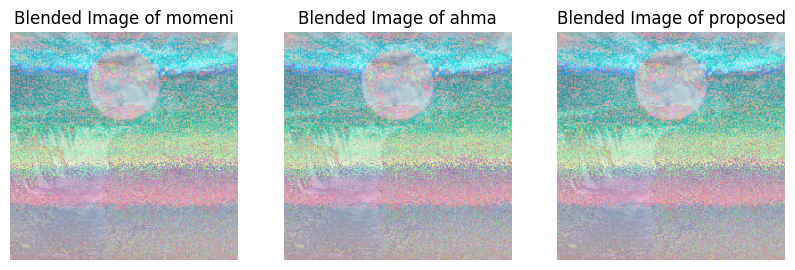

Momeni (CN) → PSNR: 12.92, SSIM: 0.3427
Momeni (CN) → PSNR: 12.99, SSIM: 0.3487
Momeni (CN) → PSNR: 13.00, SSIM: 0.3489


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Local image paths
image1_path = "/content/moon_1-256x256.jpg"
image2_path = "/content/pexels-jonnylew-1928279-256x256.jpg"

# Read the images using OpenCV
image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)
img1 = cv2.resize(image1, (256, 256))
img2 = cv2.resize(image2, (256, 256))

def image_blending(image1, image2, multiplier):
  scale=128
  img1_ = image1.astype(np.float32)*scale
  img2_ = image2.astype(np.float32)*scale
  alpha = 1
  beta = 0.6
  gamma = 0.5

  # Create an empty array for the blended image
  blended_image = np.zeros_like(img1_)

  # Iterate through each pixel and apply the multiplier
  rows, cols, channels = img1_.shape
  for i in range(rows):
    for j in range(cols):
      for k in range(channels):
        blended_image[i, j, k] = (multiplier(img1_[i, j, k], int(alpha*scale)) + multiplier(img2_[i, j, k], int(beta*scale)) + int(gamma*scale))/scale

  image2 = cv2.normalize(blended_image, None, 0, 255, cv2.NORM_MINMAX)
  blended = np.clip(image2, 0, 255).astype(np.uint8)
  return blended



# Display the blended image
blended_result = image_blending(img1, img2, momeni_multiplier)
blended_result1 = image_blending(img1, img2, ahma_multiplier)
blended_result2 =  image_blending(img1, img2, proposed_multiplier)
plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(blended_result, cv2.COLOR_BGR2RGB))
plt.title('Blended Image of momeni')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(blended_result1, cv2.COLOR_BGR2RGB))
plt.title('Blended Image of ahma')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(blended_result2, cv2.COLOR_BGR2RGB))
plt.title('Blended Image of proposed')
plt.axis('off')
plt.show()

p, s = print_psnr_ssim("Momeni (CN)",blended_image, blended_result)
print(f"Momeni (CN) → PSNR: {p:.2f}, SSIM: {s:.4f}")
p, s = print_psnr_ssim("ahma (CN)",blended_image, blended_result1)
print(f"Momeni (CN) → PSNR: {p:.2f}, SSIM: {s:.4f}")
p, s = print_psnr_ssim("proposed (CN)",blended_image, blended_result2)
print(f"Momeni (CN) → PSNR: {p:.2f}, SSIM: {s:.4f}")



In [ ]:
#psnr and ssim
import numpy as np
def print_psnr_ssim(label,image1, image2):
  img_1=image1.astype(np.float64)
  img_2=image2.astype(np.float64)
  mse = np.mean((img_1 - img_2) ** 2)
  mse_final=0
  if mse == 0:
      mse_final=float('inf')
  else:
      mse_final = 20 * np.log10(255 / np.sqrt(mse))
  max_pixel=255
  C1 = (0.01 * max_pixel) ** 2
  C2 = (0.03 * max_pixel) ** 2

  mu1 = np.mean(img_1)
  mu2 = np.mean(img_2)
  sigma1_sq = np.var(img_1)
  sigma2_sq = np.var(img_2)
  sigma12 = np.mean((img_1 - mu1) * (img_2 - mu2))

  numerator = (2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)
  denominator = (mu1 ** 2 + mu2 ** 2 + C1) * (sigma1_sq + sigma2_sq + C2)
  ssim_val = numerator / denominator
  return print(f"{label} → PSNR: {mse_final:.2f}, SSIM: {ssim_val:.4f}")

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Local image paths
image1_path = "/content/moon_1-256x256.jpg"
image2_path = "/content/pexels-jonnylew-1928279-256x256.jpg"

# Read the images using OpenCV
image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)
img1 = cv2.resize(image1, (256, 256))
img2 = cv2.resize(image2, (256, 256))

def image_blending1(image1, image2, multiplier):
  img1_ = image1.astype(np.float32)
  img2_ = image2.astype(np.float32)

  # Scale alpha and beta to integers for multiplier use
  alpha1 = int(round(1 * 255))
  beta1 = int(round(0.6 * 255))  # This scaling allows integer-only multiplication
  gamma = 0.5  # Keep gamma as float to match OpenCV's behavior

  # Create an empty array for the blended image
  blended_image = np.zeros_like(img1_)

  # Iterate through each pixel and apply the multiplier
  rows, cols, channels = img1_.shape
  for i in range(rows):
    for j in range(cols):
      for k in range(channels):
        a = int(round(img1_[i, j, k]))
        b = int(round(img2_[i, j, k]))

        # Use the scaled alpha/beta for multiplication
        val = (multiplier(a, alpha1) + multiplier(b, beta1)) / 255.0 + gamma

        # Round and assign to output
        blended_image[i, j, k] = round(val)

  # Final clip to ensure valid pixel range
  blended = np.clip(blended_image, 0, 255).astype(np.uint8)
  return blended


BLENDING WITH EXACT → PSNR: 72.21, SSIM: 1.0000


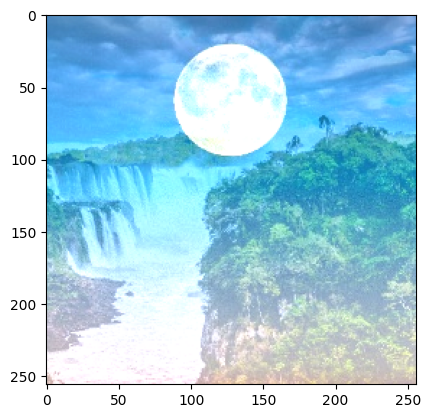

In [ ]:
blended_ = image_blending1(img1, img2, plain_mul)
plt.imshow(cv2.cvtColor(blended_, cv2.COLOR_BGR2RGB))
print_psnr_ssim("BLENDING WITH EXACT",blended_image, blended_)

In [ ]:
print_psnr_ssim("BLENDING WITH EXACT", blended_image, blended_)

blended_image = image_blending1(img1, img2, momeni_multiplier)
print_psnr_ssim("BLENDING WITH Momeni (CN)", blended_image, blended_)

blended_image = image_blending1(img1, img2, venka_multiplier)
print_psnr_ssim("BLENDING WITH Venka (CN)", blended_image, blended_)

blended_image = image_blending1(img1, img2, yang2_multiplier)
print_psnr_ssim("BLENDING WITH Yang2 (CN)", blended_image, blended_)

blended_image = image_blending1(img1, img2, akbar2_multiplier)
print_psnr_ssim("BLENDING WITH Akbar2 (CN)", blended_image, blended_)

blended_image = image_blending1(img1, img2, ahma_multiplier)
print_psnr_ssim("BLENDING WITH Ahma (CN)", blended_image, blended_)

blended_image = image_blending1(img1, img2, proposed_multiplier)
print_psnr_ssim("BLENDING WITH Proposed (CN)", blended_image, blended_)

blended_image = image_blending1(img1, img2, momeni_multiplier_cfull)
print_psnr_ssim("BLENDING WITH Momeni (CFULL)", blended_image, blended_)

blended_image = image_blending1(img1, img2, venka_multiplier_cfull)
print_psnr_ssim("BLENDING WITH Venka (CFULL)", blended_image, blended_)

blended_image = image_blending1(img1, img2, yang2_multiplier_cfull)
print_psnr_ssim("BLENDING WITH Yang2 (CFULL)", blended_image, blended_)

blended_image = image_blending1(img1, img2, akbar2_multiplier_cfull)
print_psnr_ssim("BLENDING WITH Akbar2 (CFULL)", blended_image, blended_)

blended_image = image_blending1(img1, img2, ahma_multiplier_cfull)
print_psnr_ssim("BLENDING WITH Ahma (CFULL)", blended_image, blended_)

blended_image = image_blending1(img1, img2, proposed_multiplier_cfull)
print_psnr_ssim("BLENDING WITH Proposed (CFULL)", blended_image, blended_)

BLENDING WITH EXACT → PSNR: 72.21, SSIM: 1.0000
BLENDING WITH Momeni (CN) → PSNR: 31.57, SSIM: 0.9935
BLENDING WITH Venka (CN) → PSNR: 32.33, SSIM: 0.9945
BLENDING WITH Yang2 (CN) → PSNR: 32.26, SSIM: 0.9943
BLENDING WITH Akbar2 (CN) → PSNR: 32.34, SSIM: 0.9945
BLENDING WITH Ahma (CN) → PSNR: 31.98, SSIM: 0.9943
BLENDING WITH Proposed (CN) → PSNR: 32.18, SSIM: 0.9942
BLENDING WITH Momeni (CFULL) → PSNR: 15.21, SSIM: 0.7629
BLENDING WITH Venka (CFULL) → PSNR: 20.98, SSIM: 0.9492
BLENDING WITH Yang2 (CFULL) → PSNR: 21.48, SSIM: 0.9366
BLENDING WITH Akbar2 (CFULL) → PSNR: 20.46, SSIM: 0.9284
BLENDING WITH Ahma (CFULL) → PSNR: 17.51, SSIM: 0.9247
BLENDING WITH Proposed (CFULL) → PSNR: 23.06, SSIM: 0.9501


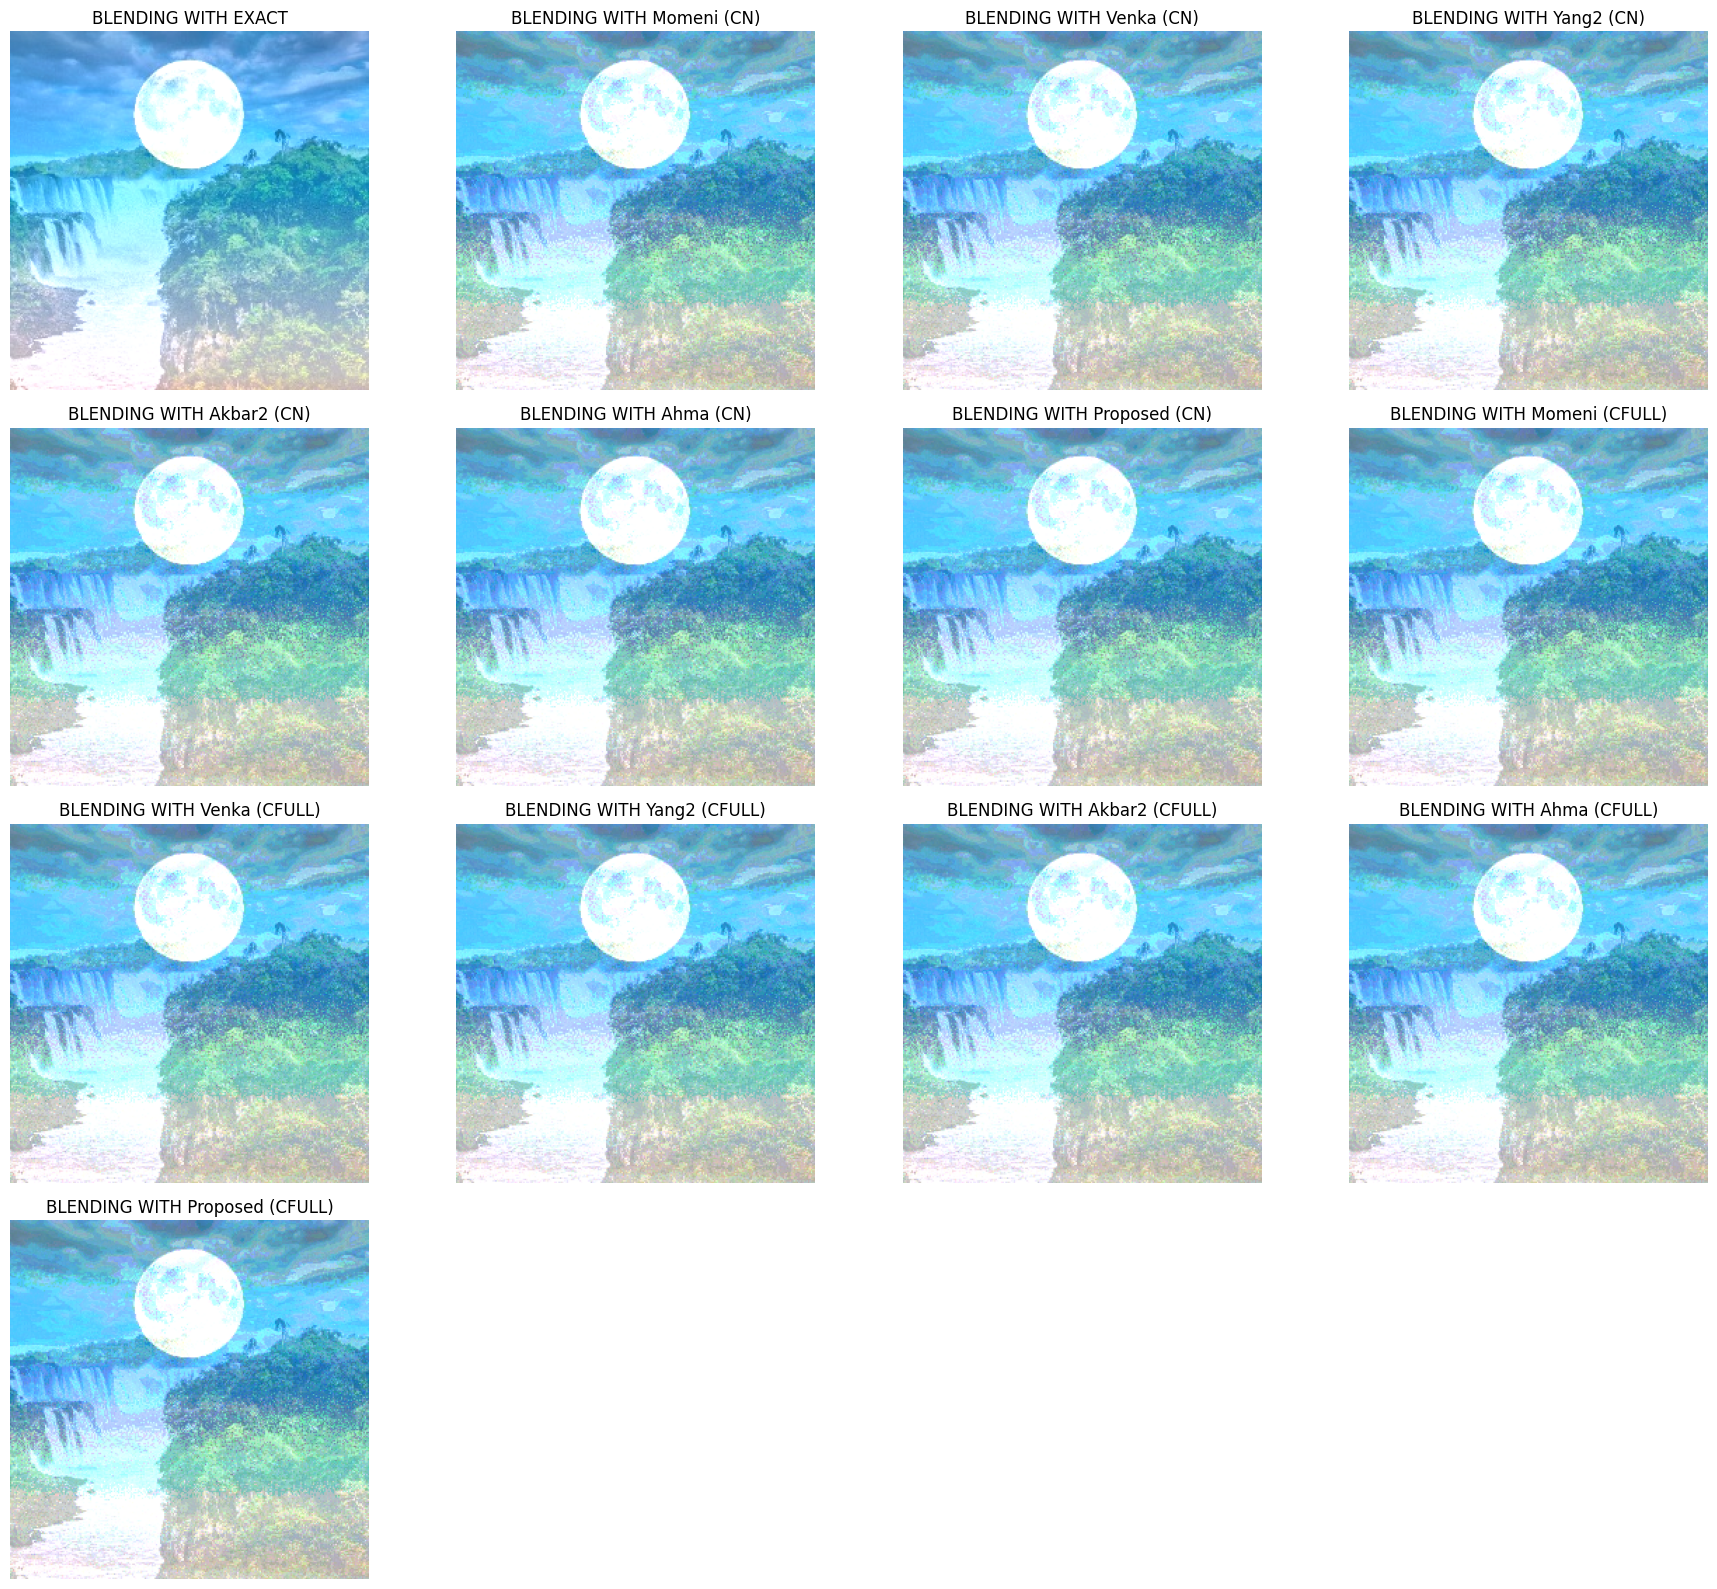

In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(18, 16))

# 1. Exact
plt.subplot(4, 4, 1)
plt.imshow(cv2.cvtColor(blended_, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH EXACT")
plt.axis('off')

# 2. Momeni (CN)
plt.subplot(4, 4, 2)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Momeni (CN)")
plt.axis('off')

# 3. Venka (CN)
plt.subplot(4, 4, 3)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Venka (CN)")
plt.axis('off')

# 4. Yang2 (CN)
plt.subplot(4, 4, 4)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Yang2 (CN)")
plt.axis('off')

# 5. Akbar2 (CN)
plt.subplot(4, 4, 5)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Akbar2 (CN)")
plt.axis('off')

# 6. Ahma (CN)
plt.subplot(4, 4, 6)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Ahma (CN)")
plt.axis('off')

# 7. Proposed (CN)
plt.subplot(4, 4, 7)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Proposed (CN)")
plt.axis('off')

# 8. Momeni (CFULL)
plt.subplot(4, 4, 8)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Momeni (CFULL)")
plt.axis('off')

# 9. Venka (CFULL)
plt.subplot(4, 4, 9)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Venka (CFULL)")
plt.axis('off')

# 10. Yang2 (CFULL)
plt.subplot(4, 4, 10)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Yang2 (CFULL)")
plt.axis('off')

# 11. Akbar2 (CFULL)
plt.subplot(4, 4, 11)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Akbar2 (CFULL)")
plt.axis('off')

# 12. Ahma (CFULL)
plt.subplot(4, 4, 12)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Ahma (CFULL)")
plt.axis('off')

# 13. Proposed (CFULL)
plt.subplot(4, 4, 13)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title("BLENDING WITH Proposed (CFULL)")
plt.axis('off')

plt.tight_layout()
plt.show()
